In [1]:
!pip install pennylane
!pip install pennylane-qulacs

In [2]:
from pennylane import qaoa
from pennylane import numpy as np
import pennylane as qml
from matplotlib import pyplot as plt
import networkx as nx
import time

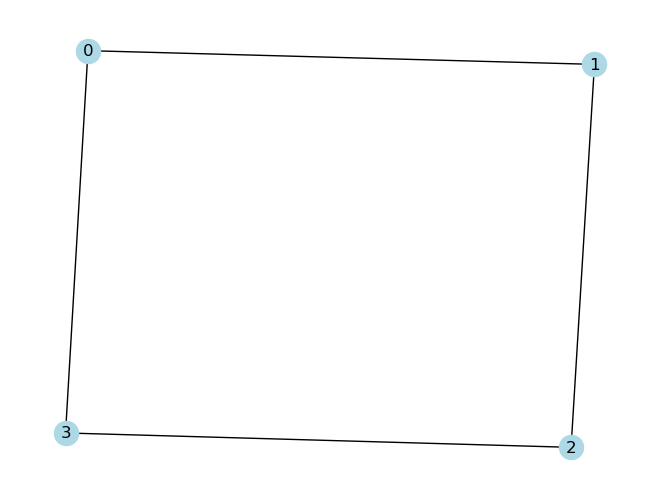

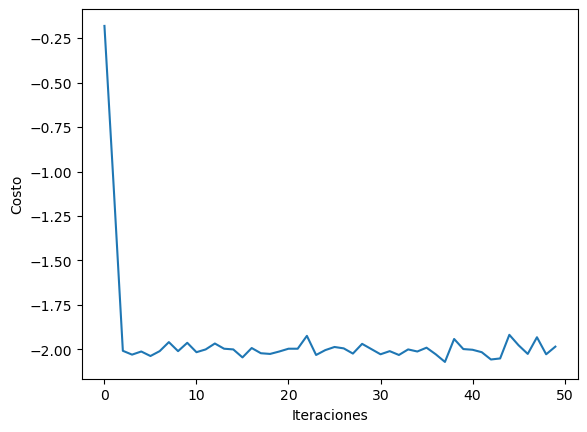

Parámetros óptimos: [1.13016811 2.35882739]
Valor final del costo: -1.984375
Tiempo total de ejecución: 6.156781196594238 segundos


In [3]:
graph = nx.Graph([(0,1), (1,2), (2,3), (3,0)])
nx.draw(graph, with_labels=True, node_color='lightblue')
plt.show()

cost_h, mixer_h = qaoa.maxcut(graph)

n_wires = len(graph.nodes)
dev = qml.device('default.qubit', wires=n_wires)

@qml.set_shots(1024)
@qml.qnode(dev)
def circuit(params):
    qaoa.cost_layer(params[0], cost_h)
    qaoa.mixer_layer(params[1], mixer_h)
    return qml.expval(cost_h)

np.random.seed(42)
params = np.random.uniform(0, np.pi, (2,))
opt = qml.GradientDescentOptimizer(stepsize=0.1)

steps = 50
costs = []
start = time.time()

for _ in range(steps):
    params, cost = opt.step_and_cost(circuit, params)
    costs.append(cost)

end = time.time()

plt.plot(costs)
plt.xlabel('Iteraciones')
plt.ylabel('Costo')
plt.show()

print("Parámetros óptimos:", params)
print("Valor final del costo:", cost)
print("Tiempo total de ejecución:", end - start, "segundos")
